# Session 2 — Image basics: pixels, channels and colour

**Computer Vision & Speech Recognition · Joshua Cole · 14 September 2026**

Exercises posed in class in session 2. In class we re-downloaded MILK10k inside Colab and wrote a tiny
`common` package on the fly; here the same exercises run against this repository's structure instead —
the dataset already lives in `data/raw/milk10k/` (session 1) and the loaders in `src/milk10k.py`.

What we cover:

1. Load the metadata and pick one lesion image
2. Open the image with PIL and display it
3. The image as a NumPy array — shape, dtype, value range
4. Individual pixels and a small crop
5. The three colour channels (R, G, B) and their means
6. Building images from scratch — pure colour swatches
7. *Extension:* channel histograms, and clinical vs dermoscopic views of the same lesion

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# make `src/` importable from the notebooks/ folder
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT))
from src import milk10k

print("project root:", PROJECT_ROOT)
print("image dir   :", milk10k.IMAGE_DIR, "->", milk10k.IMAGE_DIR.exists())

project root: /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition
image dir   : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k/images -> True


## 2. Load the metadata and pick one image

`load_images_table()` gives one row per image (10,480 rows) with the lesion label merged in and a
ready-made `path` column, so we do not need the `image_path()` helper we wrote in class.

In [2]:
df = milk10k.load_images_table()
print(len(df), "images,", df["lesion_id"].nunique(), "lesions")
df[["isic_id", "lesion_id", "image_type", "label", "label_name"]].head()

10480 images, 5240 lesions


,isic_id,lesion_id,image_type,label,label_name
0,ISIC_0051817,IL_1612768,dermoscopic,SCCKA,Squamous cell carcinoma / keratoacanthoma
1,ISIC_0073863,IL_2547802,dermoscopic,NV,Melanocytic nevus
2,ISIC_0075884,IL_9270970,clinical,NV,Melanocytic nevus
3,ISIC_0076255,IL_8089688,dermoscopic,BCC,Basal cell carcinoma
4,ISIC_0077054,IL_5271098,dermoscopic,BCC,Basal cell carcinoma


As in class, take the first row of the table. Its path is built from the `isic_id`.

In [3]:
row = df.iloc[0]
img_path = row["path"]
print(img_path.name, "|", row["image_type"], "|", row["label_name"])
print("exists:", img_path.exists())

ISIC_0051817.jpg | dermoscopic | Squamous cell carcinoma / keratoacanthoma
exists: True


## 3. Open the image with PIL

`Image.open` reads the JPEG lazily; `.convert("RGB")` guarantees three channels (some files can be
greyscale or carry an alpha channel). `.size` is `(width, height)` — note the order, it is the
opposite of NumPy's `(rows, cols)`.

In [4]:
img = Image.open(img_path).convert("RGB")
print("size (W, H):", img.size, "| mode:", img.mode, "| format:", Image.open(img_path).format)

size (W, H): (600, 450) | mode: RGB | format: JPEG


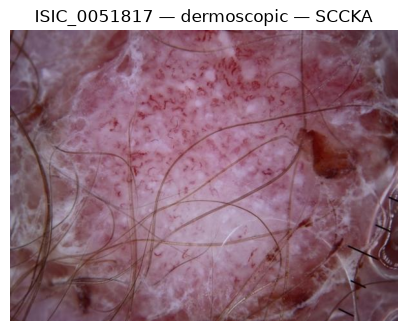

In [5]:
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"{row['isic_id']} — {row['image_type']} — {row['label']}")
plt.axis("off")
plt.show()

## 4. The image as a NumPy array

`np.array(img)` turns the picture into a tensor of shape **(height, width, 3)** with `uint8` values in
`0–255`. Every model we build later will start from exactly this array (usually rescaled to `0–1`).

In [6]:
arr = np.array(img)
print("shape (H, W, C):", arr.shape)
print("dtype          :", arr.dtype)
print("min / max      :", arr.min(), "/", arr.max())
print("bytes in memory:", arr.nbytes / 1e6, "MB")

shape (H, W, C): (450, 600, 3)
dtype          : uint8
min / max      : 0 / 230
bytes in memory: 0.81 MB


## 5. Individual pixels

`arr[0, 0]` is the top-left pixel: three numbers, one per channel `[R, G, B]`. Slicing a `5 × 5`
corner and showing it lets us see individual pixels as blocks.

top-left pixel [R, G, B]: [117  74  68]
centre pixel   [R, G, B]: [184 147 178]


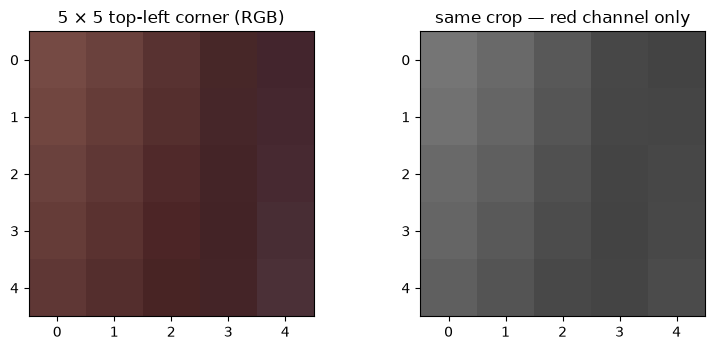

red value at (0,0): 117
red value at (0,1): 106

red channel of the crop:
     0    1   2   3   4
0  117  106  88  71  67
1  113  101  85  70  69
2  106   95  80  68  71
3  101   90  76  67  72
4   95   84  72  68  75


In [7]:
print("top-left pixel [R, G, B]:", arr[0, 0])
print("centre pixel   [R, G, B]:", arr[arr.shape[0] // 2, arr.shape[1] // 2])

crop = arr[0:5, 0:5]

fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
axes[0].imshow(crop)
axes[0].set_title("5 × 5 top-left corner (RGB)")
axes[1].imshow(crop[:, :, 0], cmap="gray", vmin=0, vmax=255)
axes[1].set_title("same crop — red channel only")
for ax in axes:
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
plt.tight_layout()
plt.show()

print("red value at (0,0):", arr[0, 0, 0])
print("red value at (0,1):", arr[0, 1, 0])
print("\nred channel of the crop:")
print(pd.DataFrame(crop[:, :, 0]))

## 6. The three colour channels

Index the last axis to pull out one channel at a time. Displayed with a grey colormap, each channel is
just a brightness map: bright = a lot of that colour. Skin and lesions are dominated by red, so the red
channel is usually the brightest and the blue channel the darkest — the means confirm it.

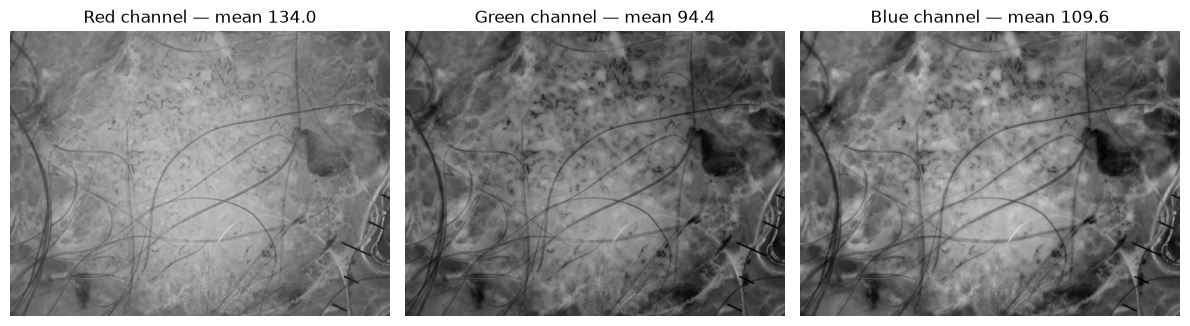

Red   mean:  134.0   std:  29.0
Green mean:   94.4   std:  30.6
Blue  mean:  109.6   std:  36.7


In [8]:
channels = [("Red", 0), ("Green", 1), ("Blue", 2)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, idx) in zip(axes, channels):
    ax.imshow(arr[:, :, idx], cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"{name} channel — mean {arr[:, :, idx].mean():.1f}")
    ax.axis("off")
plt.tight_layout()
plt.show()

for name, idx in channels:
    print(f"{name:5s} mean: {arr[:, :, idx].mean():6.1f}   std: {arr[:, :, idx].std():5.1f}")

## 7. Building an image from scratch — colour swatches

An image is only an array, so we can make one with `np.full`. A `5 × 5 × 3` block filled with a single
`(R, G, B)` triple is a flat colour swatch. White is all channels at 255, black is all at 0, and the
primaries have a single channel at 255.

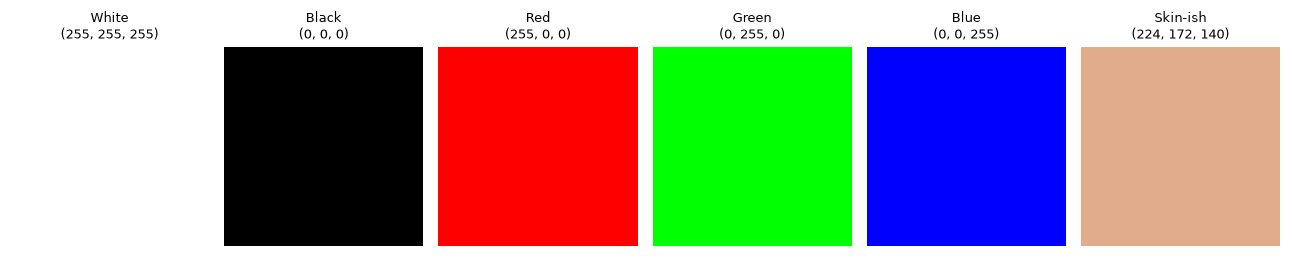

In [9]:
swatches = {
    "White": (255, 255, 255),
    "Black": (0, 0, 0),
    "Red":   (255, 0, 0),
    "Green": (0, 255, 0),
    "Blue":  (0, 0, 255),
    "Skin-ish": (224, 172, 140),   # roughly the mean colour of the image above
}

fig, axes = plt.subplots(1, len(swatches), figsize=(13, 2.6))
for ax, (name, rgb) in zip(axes, swatches.items()):
    ax.imshow(np.full((5, 5, 3), rgb, dtype=np.uint8))
    ax.set_title(f"{name}\n{rgb}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 8. Extension — channel histograms, and the two views of one lesion

Two small additions to what we did in class.

**8.1 Histograms.** The channel means hide the *distribution* of values. A histogram per channel shows
where the pixels actually sit (e.g. whether the red channel is saturating near 255).

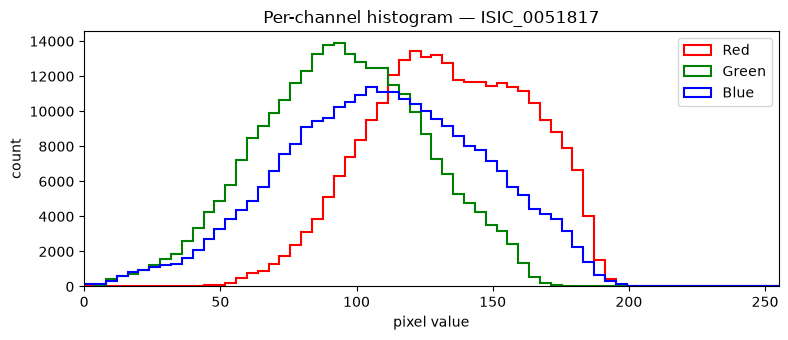

In [10]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for name, idx in channels:
    ax.hist(arr[:, :, idx].ravel(), bins=64, range=(0, 255), histtype="step",
            linewidth=1.5, color=name.lower(), label=name)
ax.set_xlabel("pixel value"); ax.set_ylabel("count"); ax.set_xlim(0, 255)
ax.set_title(f"Per-channel histogram — {row['isic_id']}")
ax.legend()
plt.tight_layout()
plt.show()

**8.2 Clinical vs dermoscopic.** Every MILK10k lesion has both a clinical close-up and a dermoscopic
image. Loading the pair for the same `lesion_id` shows how different the two modalities are as arrays —
different resolution, brightness and colour balance — which is why session 1 concluded they need
per-modality normalisation.

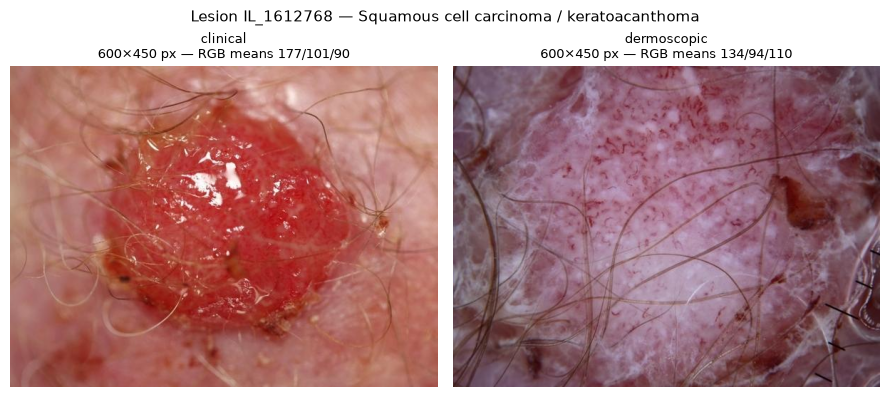

In [11]:
pair = df[df["lesion_id"] == row["lesion_id"]].sort_values("image_type")

fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, (_, r) in zip(axes, pair.iterrows()):
    a = np.array(Image.open(r["path"]).convert("RGB"))
    ax.imshow(a)
    ax.set_title(f"{r['image_type']}\n{a.shape[1]}×{a.shape[0]} px — "
                 f"RGB means {a[..., 0].mean():.0f}/{a[..., 1].mean():.0f}/{a[..., 2].mean():.0f}",
                 fontsize=9)
    ax.axis("off")
fig.suptitle(f"Lesion {row['lesion_id']} — {row['label_name']}", fontsize=11)
plt.tight_layout()
plt.show()

## 9. Takeaways

- A colour image is a `(height, width, 3)` array of `uint8` values in `0–255`; PIL reports size as
  `(width, height)` — the opposite order.
- A pixel is an `[R, G, B]` triple; indexing the last axis selects one channel, which displays as a
  brightness map.
- Skin images are red-dominated: the red channel has the highest mean and the blue the lowest.
- Images can be constructed as easily as they are read (`np.full`), which is handy for tests and masks.
- The clinical and dermoscopic views of the same lesion differ in resolution and colour statistics —
  they must be normalised separately before going into a model.